<a href="https://colab.research.google.com/github/Flipflop-ux/insider-threat-detection-system/blob/main/Confusion_Matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

INPUT_FILE = "/content/drive/MyDrive/insider_threat/data/anomaly_scores.csv"
CHART_DIR  = "/content/drive/MyDrive/insider_threat/charts"

df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} users")

Mounted at /content/drive
Loaded 500 users


In [15]:
# CELL 2: Add ground truth labels
# These are the 15 malicious users your generator created
# Replace with your actual bad_users list if different

BAD_USERS = [
    'U0457', 'U0303', 'U0013', 'U0053', 'U0347',
    'U0115', 'U0126', 'U0141', 'U0072', 'U0045',
    'U0378', 'U0380', 'U0058', 'U0328', 'U0280'
]

df['true_label'] = df['user'].isin(BAD_USERS).astype(int)  # 1 = malicious
df['pred_label'] = df['is_anomaly'].astype(int)             # 1 = flagged

print(f"Known malicious users : {df['true_label'].sum()}")
print(f"Flagged by model      : {df['pred_label'].sum()}")


Known malicious users : 15
Flagged by model      : 25


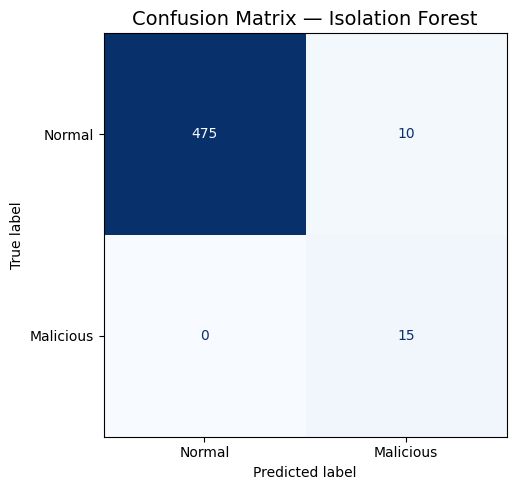

Saved!


In [16]:
# CELL 3: Confusion matrix
cm = confusion_matrix(df['true_label'], df['pred_label'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Malicious']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Isolation Forest', fontsize=14)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/06_confusion_matrix.png", dpi=150)
plt.show()
print("Saved!")

In [17]:
# CELL 4: Precision, Recall, F1
print("=" * 45)
print("  CLASSIFICATION REPORT")
print("=" * 45)
print(classification_report(
    df['true_label'],
    df['pred_label'],
    target_names=['Normal', 'Malicious']
))

# Pull out the key numbers
from sklearn.metrics import precision_score, recall_score, f1_score

p = precision_score(df['true_label'], df['pred_label'])
r = recall_score(df['true_label'], df['pred_label'])
f = f1_score(df['true_label'], df['pred_label'])

print(f"Precision : {p:.2f}  (of flagged users, how many were actually malicious)")
print(f"Recall    : {r:.2f}  (of malicious users, how many did we catch)")
print(f"F1 Score  : {f:.2f}  (balance of precision and recall)")

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       485
   Malicious       0.60      1.00      0.75        15

    accuracy                           0.98       500
   macro avg       0.80      0.99      0.87       500
weighted avg       0.99      0.98      0.98       500

Precision : 0.60  (of flagged users, how many were actually malicious)
Recall    : 1.00  (of malicious users, how many did we catch)
F1 Score  : 0.75  (balance of precision and recall)


In [18]:
# CELL 5: Train Local Outlier Factor on same features
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    "total_logins", "off_hours_login_rate", "weekend_login_rate",
    "unique_pcs_used", "avg_login_hour", "total_file_events",
    "sensitive_file_rate", "file_deletions", "file_copies",
    "off_hours_file_rate", "total_emails", "external_email_rate",
    "attachment_rate", "avg_email_size", "off_hours_email_rate",
    "usb_connections", "off_hours_usb_rate",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].values
X_scaled = StandardScaler().fit_transform(X)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof.fit_predict(X_scaled)
df['lof_pred'] = (lof_preds == -1).astype(int)

print(f"LOF flagged : {df['lof_pred'].sum()} users")

LOF flagged : 25 users


In [19]:
# CELL 6: Compare the two models
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Isolation Forest': df['pred_label'],
    'Local Outlier Factor': df['lof_pred']
}

print("=" * 55)
print(f"{'Model':<25} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print("=" * 55)
for name, preds in models.items():
    p = precision_score(df['true_label'], preds)
    r = recall_score(df['true_label'], preds)
    f = f1_score(df['true_label'], preds)
    print(f"{name:<25} {p:>10.2f} {r:>10.2f} {f:>8.2f}")
print("=" * 55)

Model                      Precision     Recall       F1
Isolation Forest                0.60       1.00     0.75
Local Outlier Factor            0.60       1.00     0.75


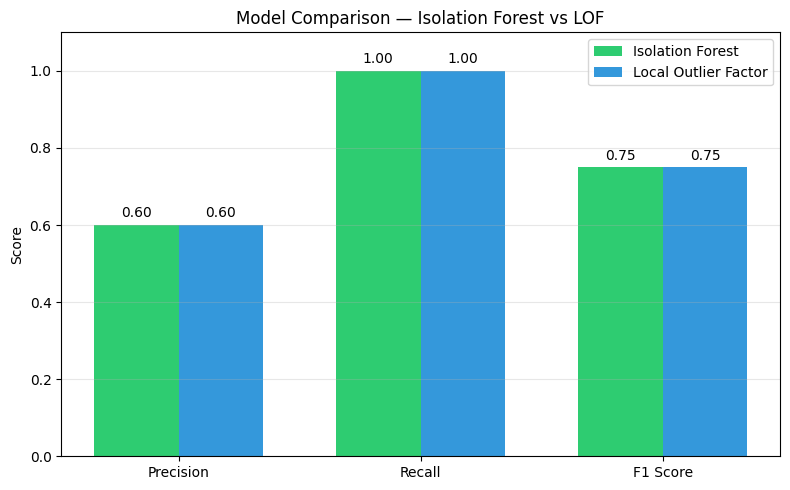

Saved!


In [20]:
# CELL 7: Bar chart comparison
metrics = ['Precision', 'Recall', 'F1 Score']

if_scores = [
    precision_score(df['true_label'], df['pred_label']),
    recall_score(df['true_label'], df['pred_label']),
    f1_score(df['true_label'], df['pred_label'])
]
lof_scores = [
    precision_score(df['true_label'], df['lof_pred']),
    recall_score(df['true_label'], df['lof_pred']),
    f1_score(df['true_label'], df['lof_pred'])
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, if_scores,  width, label='Isolation Forest',     color='#2ecc71')
ax.bar(x + width/2, lof_scores, width, label='Local Outlier Factor', color='#3498db')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Isolation Forest vs LOF')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (iv, lv) in enumerate(zip(if_scores, lof_scores)):
    ax.text(i - width/2, iv + 0.02, f'{iv:.2f}', ha='center', fontsize=10)
    ax.text(i + width/2, lv + 0.02, f'{lv:.2f}', ha='center', fontsize=10)

fig.tight_layout()
fig.savefig(f"{CHART_DIR}/07_model_comparison.png", dpi=150)
plt.show()
print("Saved!")
